#Installing Libraries and Kaggle Setup

Install Libraries

In [1]:

!pip install kaggle tensorflow numpy pandas matplotlib opencv-python


Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


kaggle.json

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shrawak","key":"797d1d1671b336c20880cb69d6ddb64c"}'}

Configure Kaggle In Collab

In [4]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Downloading Kaggle dataset

In [5]:
!kaggle datasets download -d techsash/waste-classification-data

Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data
License(s): CC-BY-SA-4.0
 98% 417M/427M [00:09<00:00, 35.1MB/s]
100% 427M/427M [00:09<00:00, 49.0MB/s]


Extracting The Dataset

In [12]:
import zipfile
with zipfile.ZipFile("waste-classification-data.zip", 'r') as zip_ref:
    zip_ref.extractall("waste_data")

#Pre Processing The Data

Checking the Data Structure

In [9]:
import os
os.listdir("waste_data")


['DATASET', 'dataset']

In [10]:
import shutil

# Deleting the duplicate 'dataset' folder
shutil.rmtree("waste_data/dataset")
print("'dataset' folder deleted successfully!")


'dataset' folder deleted successfully!


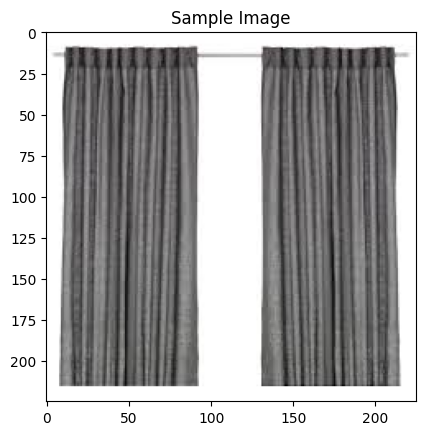

In [11]:
import matplotlib.pyplot as plt
import cv2

sample_image = cv2.imread("/content/waste_data/DATASET/TEST/R/R_10022.jpg")  # Replace with an actual image path
plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))
plt.title("Sample Image")
plt.show()

Load and Preprocess Data with TensorFlow/Keras

In [13]:
import tensorflow as tf

# Define paths
train_dir = "waste_data/DATASET/TRAIN"
test_dir = "waste_data/DATASET/TEST"

# Setting image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Loading training data
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical"  # For multi-class classification
)

# Loading testing data
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Normalizing the data (Rescale pixel values between 0 and 1)
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))


Found 22564 files belonging to 2 classes.
Found 2513 files belonging to 2 classes.


Adding Validation Split

In [14]:
# Calculating the number of batches for validation
val_size = int(0.2 * len(train_dataset))  # Converting to integer

# Spliting the dataset
val_dataset = train_dataset.take(val_size)
train_dataset = train_dataset.skip(val_size)


Checking size of dataset

In [15]:
print(f"Training dataset batches: {len(train_dataset)}")
print(f"Validation dataset batches: {len(val_dataset)}")


Training dataset batches: 565
Validation dataset batches: 141


#Building and Training the Model

Define the Model

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Defining the model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Comparing and Training The Model

Matching The Input Shape

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),  # Update input shape
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

Verifying Dataset Preprocessing

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),  # Match model input shape
    batch_size=32
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),  # Match model input shape
    batch_size=32
)

Found 22564 files belonging to 2 classes.
Using 18052 files for training.
Found 22564 files belonging to 2 classes.
Using 4512 files for validation.


 Comparing the model

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)
model.save('waste_sort_model.h5')

Epoch 1/5
565/565 ━━━━━━━━━━━━━━━━━━━━ 1198s 2s/step - accuracy: 0.8822 - loss: 0.7878 - val_accuracy: 0.7391 - val_loss: 2.0491
Epoch 2/5
565/565 ━━━━━━━━━━━━━━━━━━━━ 1207s 2s/step - accuracy: 0.9157 - loss: 0.3501 - val_accuracy: 0.7640 - val_loss: 2.2946
Epoch 3/5
565/565 ━━━━━━━━━━━━━━━━━━━━ 1219s 2s/step - accuracy: 0.9402 - loss: 0.2317 - val_accuracy: 0.7440 - val_loss: 2.4097
Epoch 4/5
565/565 ━━━━━━━━━━━━━━━━━━━━ 1219s 2s/step - accuracy: 0.9535 - loss: 0.1920 - val_accuracy: 0.7655 - val_loss: 2.3869
Epoch 5/5
565/565 ━━━━━━━━━━━━━━━━━━━━ 1178s 2s/step - accuracy: 0.9553 - loss: 0.1804 - val_accuracy: 0.7402 - val_loss: 3.8167


Testing The Model Locally

In [17]:
from tensorflow.keras.models import load_model

# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Loading the model
model_path = '/content/drive/MyDrive/WasteSort_AI_Dataset/waste_sort_model.h5'
model = load_model(model_path)
print("Model loaded successfully!")


Mounted at /content/drive


Model loaded successfully!


Uploading Image

In [18]:
from google.colab import files
from PIL import Image
import numpy as np

# Upload an image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load and preprocess the image
img = Image.open(img_path)
img = img.resize((224, 224))  # Resizing to match model input size
img_array = np.array(img) / 255.0  # Normalizing pixel values to 0-1
img_array = np.expand_dims(img_array, axis=0)  # Adding batch dimension


Saving org1.jpg to org1.jpg


Prediction Model

In [19]:
# Predicting using the model
prediction = model.predict(img_array)

# Interpret the result
if prediction[0][0] > 0.5:  # Assuming binary classification with a threshold of 0.5
    print("Prediction: Recyclable Waste")
else:
    print("Prediction: Non-Recyclable Waste")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
Prediction: Non-Recyclable Waste


Move to Drive

In [ ]:
from google.colab import drive
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Save model to Google Drive
model_path = '/content/waste_sort_model.h5'  # Update path if different
drive_path = '/content/drive/MyDrive/waste_sort_model.h5'  # Save location in Drive

shutil.copy(model_path, drive_path)
print(f"Model saved to: {drive_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to: /content/drive/MyDrive/waste_sort_model.h5


#Confusion Matrix Report

Prepare Test Data and Labels

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import numpy as np
import os

# Dataset Path
dataset_path = "/content/waste_data/DATASET/TEST"

# Preprocessing Image Function
def preprocess_image(image_path, target_size=(224, 224)):
    """
    Preprocesses an image for model prediction.

    Parameters:
        image_path (str): Path to the image.
        target_size (tuple): Target size for resizing (height, width).

    Returns:
        np.array: Preprocessed image array.
    """
    image = tf.keras.utils.load_img(image_path, target_size=target_size)  # Loading image
    img_array = tf.keras.utils.img_to_array(image)  # Converting to array
    img_array = img_array / 255.0  # Normalizing to [0, 1]
    return img_array

# Loading Test Data and Labels
def load_test_data(test_dir, target_size=(224, 224)):
    """
    Load and preprocess test data from a directory.

    Parameters:
        test_dir (str): Path to the test dataset directory.
        target_size (tuple): Target size for resizing (height, width).

    Returns:
        np.array: Preprocessed test data.
        np.array: Corresponding test labels.
    """
    data = []
    labels = []
    class_names = ['O', 'R']
    for label, folder in enumerate(class_names):
        folder_path = os.path.join(test_dir, folder)
        for image_file in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_file)
            img_array = preprocess_image(image_path, target_size)
            data.append(img_array)
            labels.append(label)

    return np.array(data), np.array(labels)

# Loading test data and labels
test_data, test_labels = load_test_data(dataset_path)

print(f"Test Data Shape: {test_data.shape}")
print(f"Test Labels Shape: {test_labels.shape}")



Test Data Shape: (2513, 224, 224, 3)
Test Labels Shape: (2513,)


Predict and Cumpute Metrices

In [ ]:
# Generating predictions
predictions = model.predict(test_data)
predicted_labels = (predictions > 0.5).astype(int).flatten()

# Confusion matrix
conf_matrix = confusion_matrix(test_labels, predicted_labels)
print("Confusion Matrix:")
print(conf_matrix)

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, predicted_labels, target_names=['Non-Recyclable', 'Recyclable']))


79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 471ms/step
Confusion Matrix:
[[ 241 1160]
 [  19 1093]]

Classification Report:
                precision    recall  f1-score   support

Non-Recyclable       0.93      0.17      0.29      1401
    Recyclable       0.49      0.98      0.65      1112

      accuracy                           0.53      2513
     macro avg       0.71      0.58      0.47      2513
  weighted avg       0.73      0.53      0.45      2513



Visualize confusion Matrix

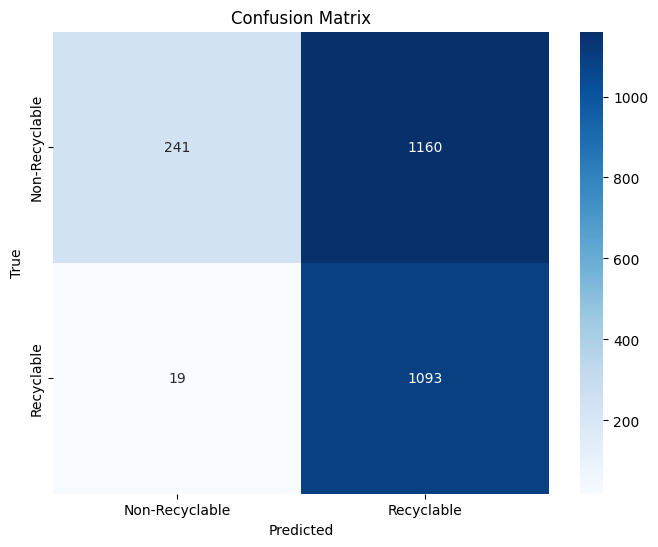

In [ ]:
# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Recyclable', 'Recyclable'], yticklabels=['Non-Recyclable', 'Recyclable'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


Sending dataset to drive

In [ ]:
from google.colab import drive
import shutil

# Mounting Google Drive
drive.mount('/content/drive')

# Defining the source and destination paths
source_path = '/content/waste_data'
destination_path = '/content/drive/MyDrive/WasteSort_AI_Dataset'

# Copying the dataset from Colab to Google Drive
shutil.copytree(source_path, destination_path)

print(f"Dataset uploaded to Google Drive at drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset uploaded to Google Drive at /content/drive/MyDrive/WasteSort_AI_Dataset


Calculationg class waights